In [1]:
import tensorflow as tf

2024-11-14 19:52:49.080699: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Deep neural network 

input > unique weights > hidden layer 1 (Activation function) > weights > hidden layer 2 (Activation function) > weights > output layer

Note: Data passing through variants straight through known as feed forward neural network

Compare output to intended output > loss or cost function (cross entropy)

Optimization function (optimizer) > minimize the cost (AdamOptimizer)

Backpropagation: Backward motion & manipulation of weights

Feed forward + Back propogation = Epoch (1 complete cycle)


## Neural Network with TensorFlow

## Let's train Mnist dataset

The MNIST dataset is a widely used collection of handwritten digit images, commonly employed for training and testing machine learning models, particularly in the field of image classification. The dataset consists of 28x28 pixel grayscale images of handwritten digits (0 through 9), each labeled with the corresponding digit.

In [2]:
from tensorflow.keras.datasets import mnist

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize pixel values to between 0 and 1

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


## Building Artificial Neural Network Model

In [3]:
# Reshape the images to a flat vector (784 pixels)
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [4]:
from tensorflow.keras import layers, models


# Define a simple neural network
model = models.Sequential([
    # Number of Neurons (Units), activation function, input shape
    layers.Dense(64, activation='relu', input_shape=(784,)), # input layer
    layers.Dropout(0.2),    # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

# Start Training
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 50890 (198.79 KB)
Trainable params: 50890 (198.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4029 - accuracy: 0.8821 - val_loss: 0.1904 - val_accuracy: 0.9462
Epoch 2/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2102 - accuracy: 0.9391 - val_loss: 0.1419 - val_accuracy: 0

In [5]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
train_loss, train_accuracy = model.evaluate(X_train, y_train)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")

1875/1875 [==============================] - 4s 2ms/step - loss: 0.0531 - accuracy: 0.9845

Test Accuracy: 97.46%

Training Accuracy: 98.45%


## Let's do the prediction

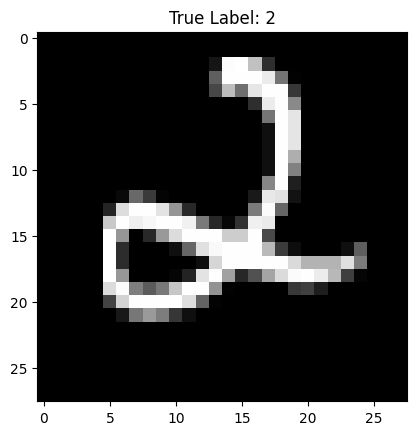

1/1 [==============================] - 0s 27ms/step
Prediction Probability:  [[5.1762214e-07 1.3029603e-09 9.9894255e-01 6.3257874e-04 2.7831196e-04
  1.8853026e-09 1.4591761e-04 3.5700364e-08 1.9478311e-07 1.3706975e-11]]
Predicted Label: 2


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Load a sample image from the MNIST dataset
sample_index = 516 # Change this index to see different samples
sample_image = X_test[sample_index].reshape(28, 28)

# Display the image
plt.imshow(sample_image, cmap='gray')
plt.title(f"True Label: {int(y_test[sample_index])}")
plt.show()

# Reshape the image for prediction
sample_image_for_prediction = sample_image.reshape(1, -1)

# Make a prediction
prediction = model.predict(sample_image_for_prediction)
print("Prediction Probability: ",prediction)
predicted_label = np.argmax(prediction)

print(f"Predicted Label: {predicted_label}")
